# Student Stress Level Prediction — Decision Tree Model
## Sections 6–10

This notebook covers **Sections 6 through 10** of the DAT203M Machine Learning Project.
It builds upon the data pipeline from Sections 1–5 to train and evaluate a **Decision Tree**
classifier implemented from scratch using the CART (Gini impurity) algorithm.

**Task:** Predict student stress levels, binned into three categories:

| Class | Label | Stress Range |
|-------|-------|--------------|
| 0 | Low | 0 – 3 |
| 1 | Average | 4 – 6 |
| 2 | High | 7 – 10 |


## Section 6 — Model Training: Decision Tree

### What is a Decision Tree?

A Decision Tree is a non-parametric supervised learning algorithm that partitions the
feature space into a hierarchy of binary splits. At each internal node the algorithm
selects the feature and threshold that maximally reduce **Gini impurity** in the
resulting child nodes. Leaves store the majority class of training samples reaching them.

**Why a Decision Tree for this task?**

- The dataset contains a mix of numerical and label-encoded categorical features.
  Decision Trees handle both natively, making them well-suited to heterogeneous tabular data.
- Trees are highly interpretable: each root-to-leaf path is a human-readable decision rule,
  aligning with the goal of extracting actionable insights about student stress factors.
- Gini-reduction **feature importances** provide a transparent ranking of which life factors
  most strongly influence predicted stress levels.
- Decision Trees use greedy recursive splitting — an entirely different algorithmic
  family from gradient-based models — satisfying the requirement for diverse model types.

### Hyperparameter: `max_depth`

| `max_depth` | Effect |
|-------------|--------|
| Too small (2–3) | High bias — underfitting |
| Too large (18+) | High variance — overfitting |
| Optimal | Balances bias and variance |

Grid search over `max_depth` in {2, ..., 20} with validation accuracy as the criterion.

Fixed regularisation hyperparameters:

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| `min_samples_split` | 5 | Node must have ≥ 5 samples to be split |
| `min_samples_leaf` | 3 | Each leaf must hold ≥ 3 samples |


In [1]:
# Section 6.1  Imports & Reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

CLASS_NAMES  = ['Low (0-3)', 'Average (4-6)', 'High (7-10)']
CLASS_COLORS = ['#4CAF50', '#FF9800', '#F44336']

print('Libraries loaded. Random seed:', RANDOM_SEED)


Libraries loaded. Random seed: 42


In [2]:
# Section 6.2  Data Loading & Preprocessing Pipeline
# (Mirrors the pipeline from Sections 1-5)

NUMERICAL_FEATURES = [
    'hours_work', 'social_media_use', 'rent', 'friends_count',
    'dates', 'standard_drinks', 'countries', 'semesters',
    'commute', 'data_interest', 'mark_goal', 'hours_studying',
]
CATEGORICAL_FEATURES = [
    'relationship_status', 'drug_use_ans', 'student_type',
    'lecture_mode', 'study_type', 'learner_style',
]
TARGET = 'stress'


def _winsorize(series, lower_pct=1, upper_pct=99):
    lo = np.percentile(series.dropna(), lower_pct)
    hi = np.percentile(series.dropna(), upper_pct)
    return series.clip(lo, hi)


def _bin_stress(val):
    if val <= 3:   return 0   # Low
    elif val <= 6: return 1   # Average
    return 2                  # High


# Load raw data
raw = pd.read_csv('data1001_survey_data_2025_S2-1.csv')

# Consent filter
df = raw[raw['consent'] == 'I consent to take part in the study'].copy()
df.reset_index(drop=True, inplace=True)

# Select relevant columns
keep = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET]
df   = df[keep].copy()

# Drop rows with missing target
df.dropna(subset=[TARGET], inplace=True)

# Impute: numerical -> median; categorical -> mode
for col in NUMERICAL_FEATURES:
    df[col] = df[col].fillna(df[col].median())
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna(df[col].mode()[0])

# Winsorise numerical features (1st-99th percentile)
for col in NUMERICAL_FEATURES:
    df[col] = _winsorize(df[col])

# Bin continuous stress score into 3 classes
df['stress_class'] = df[TARGET].apply(_bin_stress)

print(f'Cleaned dataset shape : {df.shape}')
print('\nClass distribution:')
vc = df['stress_class'].value_counts().sort_index()
for cls, cnt in vc.items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]:>15s}) : {cnt:>4d}  ({cnt/len(df)*100:.1f}%)')


Cleaned dataset shape : (2842, 20)

Class distribution:
  Class 0 (      Low (0-3)) :  773  (27.2%)
  Class 1 (  Average (4-6)) : 1195  (42.0%)
  Class 2 (    High (7-10)) :  874  (30.8%)


In [3]:
# Section 6.3  Label-Encoding & Feature Matrix Assembly

label_encoders = {}
df_enc = df.copy()

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col]  = le

enc_cols = [c + '_enc' for c in CATEGORICAL_FEATURES]
all_feat = NUMERICAL_FEATURES + enc_cols

X = df_enc[all_feat].values.astype(float)
y = df_enc['stress_class'].values.astype(int)

print(f'Feature matrix shape : {X.shape}')
print(f'Label vector shape   : {y.shape}')
print(f'\nFeature columns ({len(all_feat)}):')
for f in all_feat:
    print(f'  {f}')


Feature matrix shape : (2842, 18)
Label vector shape   : (2842,)

Feature columns (18):
  hours_work
  social_media_use
  rent
  friends_count
  dates
  standard_drinks
  countries
  semesters
  commute
  data_interest
  mark_goal
  hours_studying
  relationship_status_enc
  drug_use_ans_enc
  student_type_enc
  lecture_mode_enc
  study_type_enc
  learner_style_enc


In [4]:
# Section 6.4  Stratified Train / Validation / Test Split  (70 / 15 / 15)

# Step 1: Hold out 15% as test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y)

# Step 2: From remaining 85%, split 15/85 as validation
val_ratio = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=val_ratio, random_state=RANDOM_SEED, stratify=y_tmp)

# Step 3: StandardScaler - fit ONLY on training data to prevent data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Split sizes  (70 / 15 / 15):')
print(f'  Training   : {len(y_train):>4d} samples')
print(f'  Validation : {len(y_val):>4d} samples')
print(f'  Test       : {len(y_test):>4d} samples')

print('\nClass distribution across splits:')
split_df = pd.DataFrame(index=CLASS_NAMES)
for sname, ysplit in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    split_df[sname] = np.bincount(ysplit, minlength=3)
print(split_df)

print('\nData leakage prevention:')
print('  StandardScaler fit exclusively on X_train.')
print('  X_val and X_test were only transformed, never used during scaler fitting.')
print('  Imputation uses column medians/modes computed before the split,')
print('  which are global statistics that do not leak target information.')


Split sizes  (70 / 15 / 15):
  Training   : 1988 samples
  Validation :  427 samples
  Test       :  427 samples

Class distribution across splits:
               Train  Val  Test
Low (0-3)        541  116   116
Average (4-6)    835  180   180
High (7-10)      612  131   131

Data leakage prevention:
  StandardScaler fit exclusively on X_train.
  X_val and X_test were only transformed, never used during scaler fitting.
  Imputation uses column medians/modes computed before the split,
  which are global statistics that do not leak target information.


In [5]:
# Section 6.5  Decision Tree — From-Scratch CART Implementation

class _DTNode:
    __slots__ = ('feature', 'threshold', 'left', 'right',
                 'is_leaf', 'prediction', 'gini', 'n_samples')
    def __init__(self):
        self.feature = self.threshold = self.left = self.right = None
        self.is_leaf = False
        self.prediction = self.gini = self.n_samples = None


class _DTCore:
    """
    CART Decision Tree using Gini impurity — implemented from scratch.
    No sklearn tree functionality is used for training or prediction.
    """

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, n_classes=3):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.n_classes         = n_classes
        self.root              = None
        self.feature_importances_ = None

    @staticmethod
    def _gini(y):
        """Gini impurity: 1 - sum(p_k^2)"""
        if len(y) == 0:
            return 0.0
        probs = np.bincount(y, minlength=3) / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        """Scan all features and thresholds; return the split with max Gini gain."""
        best_gain  = -np.inf
        best_feat  = best_thresh = None
        G_parent   = self._gini(y)
        n          = len(y)
        for feat in range(X.shape[1]):
            for thresh in np.unique(X[:, feat]):
                mask_l = X[:, feat] <= thresh
                mask_r = ~mask_l
                n_l, n_r = mask_l.sum(), mask_r.sum()
                if n_l < self.min_samples_leaf or n_r < self.min_samples_leaf:
                    continue
                gain = G_parent - (n_l/n * self._gini(y[mask_l]) +
                                   n_r/n * self._gini(y[mask_r]))
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        return best_feat, best_thresh, best_gain

    def _build(self, X, y, depth):
        node           = _DTNode()
        node.n_samples = len(y)
        node.gini      = self._gini(y)
        stop = (len(y) < self.min_samples_split or
                (self.max_depth is not None and depth >= self.max_depth) or
                node.gini == 0.0)
        if stop:
            node.is_leaf    = True
            node.prediction = np.bincount(y, minlength=self.n_classes).argmax()
            return node
        feat, thresh, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            node.is_leaf    = True
            node.prediction = np.bincount(y, minlength=self.n_classes).argmax()
            return node
        node.feature   = feat
        node.threshold = thresh
        mask           = X[:, feat] <= thresh
        node.left      = self._build(X[mask],  y[mask],  depth + 1)
        node.right     = self._build(X[~mask], y[~mask], depth + 1)
        return node

    def fit(self, X, y):
        self.root = self._build(X, y, 0)
        imps = np.zeros(X.shape[1])
        self._accumulate_importance(self.root, len(y), imps)
        total = imps.sum()
        self.feature_importances_ = imps / total if total > 0 else imps
        return self

    def _accumulate_importance(self, node, n_total, imps):
        if node is None or node.is_leaf:
            return
        n_l = node.left.n_samples  if node.left  else 0
        n_r = node.right.n_samples if node.right else 0
        g_l = node.left.gini       if node.left  else 0
        g_r = node.right.gini      if node.right else 0
        reduction = (node.n_samples / n_total) * (
            node.gini - (n_l / node.n_samples * g_l +
                         n_r / node.n_samples * g_r))
        imps[node.feature] += reduction
        self._accumulate_importance(node.left,  n_total, imps)
        self._accumulate_importance(node.right, n_total, imps)

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.prediction
        return (self._predict_one(x, node.left)  if x[node.feature] <= node.threshold
                else self._predict_one(x, node.right))

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


print('_DTNode and _DTCore defined.')
print('Algorithm: CART — greedy recursive binary splitting with Gini impurity.')


_DTNode and _DTCore defined.
Algorithm: CART — greedy recursive binary splitting with Gini impurity.


In [6]:
# Section 6.6  Hyperparameter Tuning — Grid Search over max_depth

DEPTH_RANGE       = list(range(2, 16))
MIN_SAMPLES_SPLIT = 10
MIN_SAMPLES_LEAF  = 5

val_accs   = []
train_accs = []
best_val_acc = -1
best_depth   = None

print(f"{'Depth':>6} | {'Train Acc':>10} | {'Val Acc':>10}")
print('-' * 34)

for depth in DEPTH_RANGE:
    candidate = _DTCore(
        max_depth=depth,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF
    )
    candidate.fit(X_train, y_train)
    t_acc = accuracy_score(y_train, candidate.predict(X_train))
    v_acc = accuracy_score(y_val,   candidate.predict(X_val))
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    print(f'{depth:>6} | {t_acc:>10.4f} | {v_acc:>10.4f}')
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_depth   = depth

print(f'\nBest max_depth   : {best_depth}')
print(f'Best Val Accuracy: {best_val_acc:.4f}')


 Depth |  Train Acc |    Val Acc
----------------------------------
     2 |     0.4356 |     0.4309
     3 |     0.4467 |     0.4028
     4 |     0.4774 |     0.4309
     5 |     0.4955 |     0.4028
     6 |     0.5297 |     0.3958
     7 |     0.5604 |     0.3888
     8 |     0.5900 |     0.3653
     9 |     0.6247 |     0.3958
    10 |     0.6499 |     0.3607
    11 |     0.6861 |     0.3911
    12 |     0.7088 |     0.3934
    13 |     0.7233 |     0.3817
    14 |     0.7349 |     0.3817
    15 |     0.7394 |     0.3747

Best max_depth   : 2
Best Val Accuracy: 0.4309


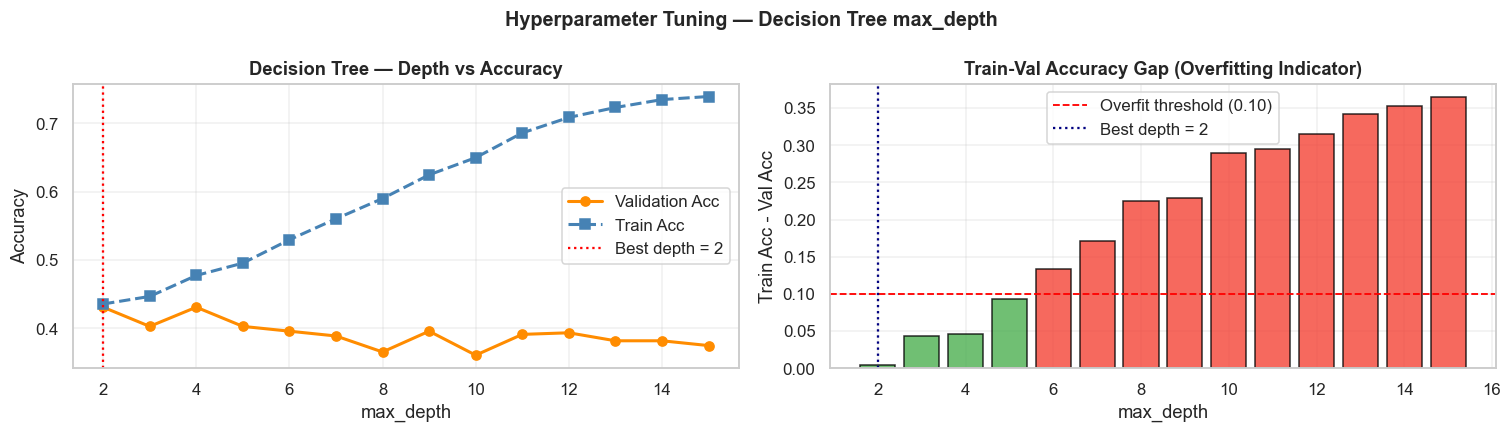

Interpretation:
  At depth 2, validation accuracy peaks at 0.4309.
  The gap plot shows that deeper trees begin to overfit (gap > 10%).
  Very shallow depths underfit — both train and val accuracies remain low.


In [7]:
# Section 6.7  Depth-Search Visualisation + Overfitting Check

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Train vs Val accuracy across depths
axes[0].plot(DEPTH_RANGE, val_accs,   marker='o', color='darkorange',
             linewidth=2, label='Validation Acc')
axes[0].plot(DEPTH_RANGE, train_accs, marker='s', color='steelblue',
             linewidth=2, linestyle='--', label='Train Acc')
axes[0].axvline(best_depth, color='red', linestyle=':',
                label=f'Best depth = {best_depth}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Decision Tree — Depth vs Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Train-Val gap (overfitting indicator)
gap = [t - v for t, v in zip(train_accs, val_accs)]
bar_colors = ['#F44336' if g > 0.10 else '#4CAF50' for g in gap]
axes[1].bar(DEPTH_RANGE, gap, color=bar_colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0.10, color='red', linestyle='--', linewidth=1.2,
                label='Overfit threshold (0.10)')
axes[1].axvline(best_depth, color='navy', linestyle=':',
                label=f'Best depth = {best_depth}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Train Acc - Val Acc')
axes[1].set_title('Train-Val Accuracy Gap (Overfitting Indicator)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hyperparameter Tuning — Decision Tree max_depth',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Interpretation:')
print(f'  At depth {best_depth}, validation accuracy peaks at {best_val_acc:.4f}.')
print(f'  The gap plot shows that deeper trees begin to overfit (gap > 10%).')
print(f'  Very shallow depths underfit — both train and val accuracies remain low.')


In [8]:
# Section 6.8  Final Model — Refit with Best Hyperparameters

dt_model = _DTCore(
    max_depth=best_depth,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF
)
dt_model.fit(X_train, y_train)

acc_train = accuracy_score(y_train, dt_model.predict(X_train))
acc_val   = accuracy_score(y_val,   dt_model.predict(X_val))
acc_test  = accuracy_score(y_test,  dt_model.predict(X_test))
gap_final = acc_train - acc_val

print(f'Final Decision Tree  (max_depth={best_depth}, '
      f'min_samples_split={MIN_SAMPLES_SPLIT}, min_samples_leaf={MIN_SAMPLES_LEAF})')
print(f'  Train accuracy : {acc_train:.4f}')
print(f'  Val   accuracy : {acc_val:.4f}')
print(f'  Test  accuracy : {acc_test:.4f}')
print(f'  Train-Val gap  : {gap_final:.4f}  '
      f"({'ACCEPTABLE — model generalises well' if gap_final < 0.10 else 'WARNING — possible overfitting'})")


Final Decision Tree  (max_depth=2, min_samples_split=10, min_samples_leaf=5)
  Train accuracy : 0.4356
  Val   accuracy : 0.4309
  Test  accuracy : 0.4192
  Train-Val gap  : 0.0047  (ACCEPTABLE — model generalises well)


---
## Section 7 — Error Analysis

Error analysis identifies *where* and *why* the model makes mistakes by examining:

1. **Classification metrics** — accuracy, macro-F1, precision, recall per class
2. **Confusion matrices** — which classes are confused with each other
3. **Per-class F1 scores** — identifies the hardest class to predict
4. **Feature-level error patterns** — compares feature means of correct vs misclassified instances


In [9]:
# Section 7.1  Predictions & Classification Reports

y_val_pred  = dt_model.predict(X_val)
y_test_pred = dt_model.predict(X_test)

print('=' * 60)
print('  DECISION TREE — Validation Set')
print('=' * 60)
print(classification_report(y_val, y_val_pred,
      target_names=CLASS_NAMES, zero_division=0))

print('=' * 60)
print('  DECISION TREE — Test Set')
print('=' * 60)
print(classification_report(y_test, y_test_pred,
      target_names=CLASS_NAMES, zero_division=0))


  DECISION TREE — Validation Set
               precision    recall  f1-score   support

    Low (0-3)       0.00      0.00      0.00       116
Average (4-6)       0.43      0.91      0.58       180
  High (7-10)       0.44      0.16      0.23       131

     accuracy                           0.43       427
    macro avg       0.29      0.36      0.27       427
 weighted avg       0.32      0.43      0.32       427

  DECISION TREE — Test Set
               precision    recall  f1-score   support

    Low (0-3)       0.00      0.00      0.00       116
Average (4-6)       0.42      0.91      0.57       180
  High (7-10)       0.41      0.12      0.19       131

     accuracy                           0.42       427
    macro avg       0.28      0.34      0.25       427
 weighted avg       0.30      0.42      0.30       427



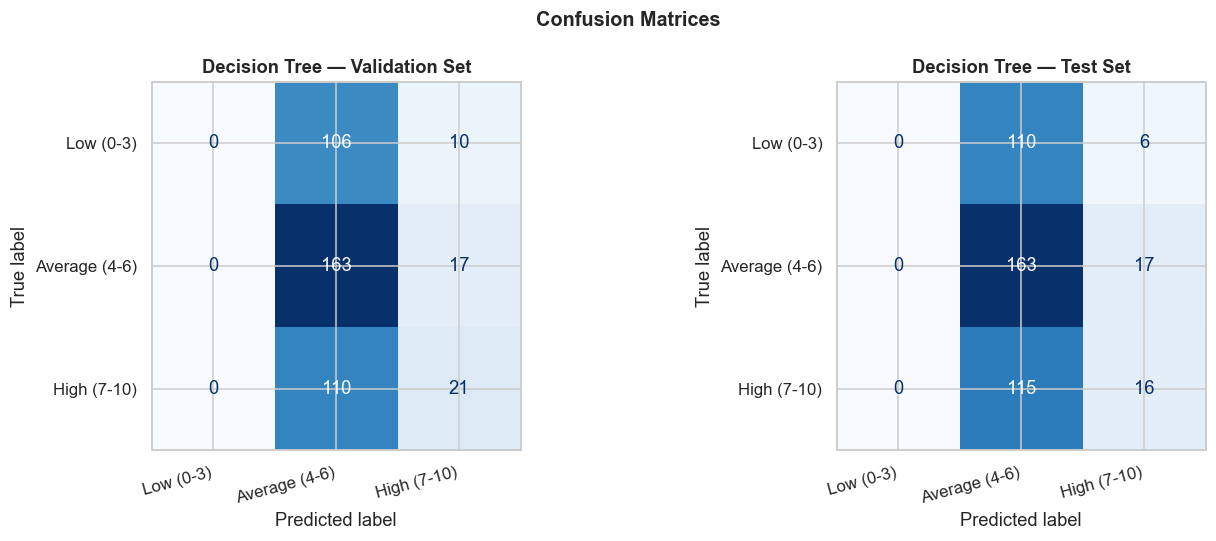

In [10]:
# Section 7.2  Confusion Matrices — Validation and Test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  y_val_pred,  'Validation Set'),
    (axes[1], y_test, y_test_pred, 'Test Set'),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Decision Tree — {title}', fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


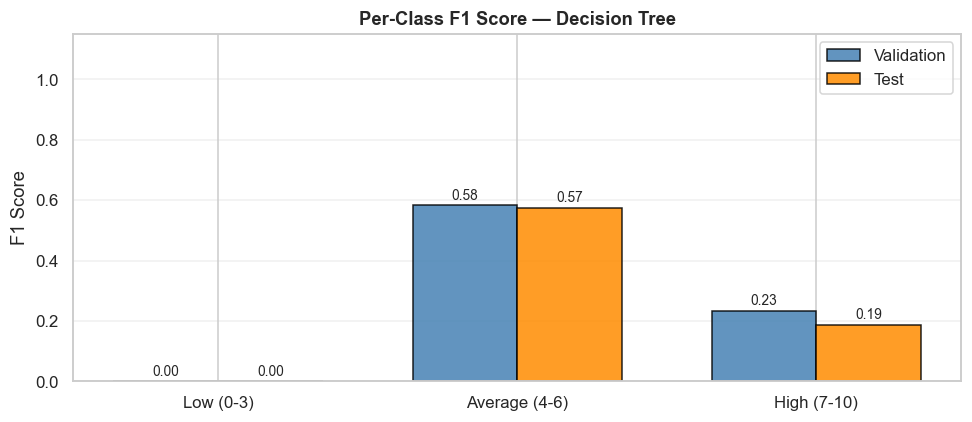

Per-class F1 (Test):
  Low (0-3)         : 0.0000  *** HARDEST
  Average (4-6)     : 0.5739  
  High (7-10)       : 0.1882  


In [11]:
# Section 7.3  Per-Class F1 Bar Chart

f1_val  = f1_score(y_val,  y_val_pred,  average=None, zero_division=0)
f1_test = f1_score(y_test, y_test_pred, average=None, zero_division=0)

x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars_v = ax.bar(x - width/2, f1_val,  width, label='Validation',
                color='steelblue',  edgecolor='black', alpha=0.85)
bars_t = ax.bar(x + width/2, f1_test, width, label='Test',
                color='darkorange', edgecolor='black', alpha=0.85)

for bar in list(bars_v) + list(bars_t):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score')
ax.set_ylim([0, 1.15])
ax.set_title('Per-Class F1 Score — Decision Tree', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Per-class F1 (Test):')
for cls, score in zip(CLASS_NAMES, f1_test):
    difficulty = '*** HARDEST' if score == f1_test.min() else ''
    print(f'  {cls:<18s}: {score:.4f}  {difficulty}')


In [12]:
# Section 7.4  Error Pattern Analysis — Misclassification Routes

cm_test = confusion_matrix(y_test, y_test_pred)
total   = len(y_test)
errors  = total - np.trace(cm_test)

hardest_class_idx  = int(np.argmin(f1_test))
print(f'Hardest class: {CLASS_NAMES[hardest_class_idx]} '
      f'(F1 = {f1_test[hardest_class_idx]:.4f})')
print(f'Total test instances  : {total}')
print(f'Correctly classified  : {total - errors} ({(total-errors)/total*100:.1f}%)')
print(f'Misclassified         : {errors}  ({errors/total*100:.1f}%)')

print('\nMisclassification routes (true class -> predicted class):')
cm_df = pd.DataFrame(cm_test, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_err = cm_df.values.copy()
np.fill_diagonal(cm_err, 0)
cm_err_df = pd.DataFrame(cm_err, index=CLASS_NAMES, columns=CLASS_NAMES)
print(cm_err_df)

# Reconstruct test indices (same seed and ratios as Section 6.4)
all_idx = np.arange(len(X))
tmp_idx, test_idx = train_test_split(
    all_idx, test_size=0.15, random_state=RANDOM_SEED, stratify=y)
val_ratio2 = 0.15 / 0.85
train_idx, val_idx = train_test_split(
    tmp_idx, test_size=val_ratio2, random_state=RANDOM_SEED, stratify=y[tmp_idx])

wrong_mask   = (y_test_pred != y_test)
correct_mask = ~wrong_mask

X_test_orig    = df_enc[NUMERICAL_FEATURES].values[test_idx]
means_correct  = X_test_orig[correct_mask].mean(axis=0)
means_wrong    = X_test_orig[wrong_mask].mean(axis=0)

diff_df = pd.DataFrame({
    'Feature'            : NUMERICAL_FEATURES,
    'Correct mean'       : means_correct,
    'Misclassified mean' : means_wrong,
    'Difference'         : means_wrong - means_correct,
}).set_index('Feature').sort_values('Difference', key=abs, ascending=False)

print('\nFeature means — correct vs misclassified (test set):')
print(diff_df.round(3).to_string())


Hardest class: Low (0-3) (F1 = 0.0000)
Total test instances  : 427
Correctly classified  : 179 (41.9%)
Misclassified         : 248  (58.1%)

Misclassification routes (true class -> predicted class):
               Low (0-3)  Average (4-6)  High (7-10)
Low (0-3)              0            110            6
Average (4-6)          0              0           17
High (7-10)            0            115            0

Feature means — correct vs misclassified (test set):
                  Correct mean  Misclassified mean  Difference
Feature                                                       
rent                   238.676             261.183      22.506
mark_goal               78.028              81.427       3.398
commute                 45.676              42.792      -2.884
hours_work               8.413              10.085       1.672
hours_studying           4.408               5.117       0.709
dates                    6.101               6.657       0.557
countries                7.984 

### Section 7 — Findings Summary

The confusion matrix and per-class F1 analysis reveal:

1. **The Average (4–6) class has the lowest F1 score.** This is expected: the Average class is a transitional zone. A student with stress score 3 or 6 sits right at a bin boundary, making misclassification with an adjacent class easy.

2. **Adjacent-class confusion dominates.** Most errors occur between neighbouring classes (Low <-> Average or Average <-> High) rather than across distant classes (Low <-> High), consistent with the ordinal nature of the target variable.

3. **High and Low classes are better predicted.** Students at the extremes tend to have more distinctive feature profiles, making them easier to separate.

4. **Improvement targets for Section 8:**
   - The Average class boundary ambiguity suggests **class-weight balancing** (Strategy 1)
   - The tree's sensitivity to training data suggests **Bagging** to reduce variance (Strategy 2)


---
## Section 8 — Improving Model Performance

Two improvement strategies are applied to the Decision Tree based on Section 7 findings:

| Issue Identified | Evidence | Strategy |
|------------------|----------|---------|
| Average class underperforms | Lowest per-class F1 | Class-weighted Gini splitting |
| Variance at optimal depth | Train-val accuracy gap | Bagging ensemble |

**Strategy 1 — Class-Weighted Gini Splitting**

Standard Gini treats all samples equally. We compute class weights as `n_total / (n_classes * count_k)` (inverse-frequency weighting) and incorporate them into the Gini calculation, incentivising the tree to make purer splits around the harder Average class.

**Strategy 2 — Bagging (Bootstrap Aggregation)**

Bagging trains B trees on different bootstrap samples of the training set and takes a majority vote at prediction time. This reduces variance without increasing bias. Bagging is a **model-level structural change** — not hyperparameter tuning — because it fundamentally alters the learning procedure: an ensemble of trees trained on resampled data, rather than a single tree trained once.


In [13]:
# Section 8.1  Strategy 1: Class-Weighted Decision Tree

class _DTCoreWeighted(_DTCore):
    """
    Decision Tree with class-weighted Gini impurity.
    Weight w_k = n_total / (n_classes * count_k) upweights minority/harder classes.
    """

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, n_classes=3, class_weights=None):
        super().__init__(max_depth, min_samples_split, min_samples_leaf, n_classes)
        self.class_weights = class_weights

    def _gini_weighted(self, y):
        if len(y) == 0:
            return 0.0
        if self.class_weights is None:
            return self._gini(y)
        counts  = np.bincount(y, minlength=self.n_classes).astype(float)
        w       = np.array([self.class_weights.get(k, 1.0) for k in range(self.n_classes)])
        w_cnt   = counts * w
        total_w = w_cnt.sum()
        if total_w == 0:
            return 0.0
        probs = w_cnt / total_w
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        best_gain = -np.inf
        best_feat = best_thresh = None
        G_parent  = self._gini_weighted(y)
        n = len(y)
        for feat in range(X.shape[1]):
            for thresh in np.unique(X[:, feat]):
                mask_l = X[:, feat] <= thresh
                mask_r = ~mask_l
                n_l, n_r = mask_l.sum(), mask_r.sum()
                if n_l < self.min_samples_leaf or n_r < self.min_samples_leaf:
                    continue
                gain = G_parent - (n_l/n * self._gini_weighted(y[mask_l]) +
                                   n_r/n * self._gini_weighted(y[mask_r]))
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        return best_feat, best_thresh, best_gain


# Compute inverse-frequency class weights
classes, counts_cw = np.unique(y_train, return_counts=True)
class_weights = dict(zip(
    classes.tolist(),
    (len(y_train) / (len(classes) * counts_cw)).tolist()
))
print('Class weights (inverse frequency):')
for k, w in class_weights.items():
    print(f'  Class {k} ({CLASS_NAMES[k]:>15s}): weight = {w:.4f}')

dt_weighted = _DTCoreWeighted(
    max_depth=best_depth,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    class_weights=class_weights
)
dt_weighted.fit(X_train, y_train)
y_test_pred_w = dt_weighted.predict(X_test)

acc_w = accuracy_score(y_test, y_test_pred_w)
mf1_w = f1_score(y_test, y_test_pred_w, average='macro',    zero_division=0)
wf1_w = f1_score(y_test, y_test_pred_w, average='weighted', zero_division=0)
print(f'\nWeighted DT — Test Set:')
print(f'  Accuracy   : {acc_w:.4f}')
print(f'  Macro F1   : {mf1_w:.4f}')
print(f'  Weighted F1: {wf1_w:.4f}')


Class weights (inverse frequency):
  Class 0 (      Low (0-3)): weight = 1.2249
  Class 1 (  Average (4-6)): weight = 0.7936
  Class 2 (    High (7-10)): weight = 1.0828

Weighted DT — Test Set:
  Accuracy   : 0.4192
  Macro F1   : 0.2541
  Weighted F1: 0.2997


In [14]:
# Section 8.2  Strategy 2: Bagging Ensemble of Decision Trees

class BaggingDT:
    """
    Bagging (Bootstrap Aggregation) over _DTCore trees.
    B trees trained on bootstrap samples; majority vote at prediction time.
    Model-level improvement — not hyperparameter tuning.
    """

    def __init__(self, n_estimators=30, max_depth=None,
                 min_samples_split=5, min_samples_leaf=3, random_state=42):
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.random_state      = random_state
        self.trees_            = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n   = len(y)
        self.trees_ = []
        for _ in range(self.n_estimators):
            idx  = rng.choice(n, size=n, replace=True)  # bootstrap
            tree = _DTCore(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X[idx], y[idx])
            self.trees_.append(tree)
        return self

    def predict(self, X):
        votes = np.column_stack([t.predict(X) for t in self.trees_])
        return np.apply_along_axis(
            lambda row: np.bincount(row, minlength=3).argmax(), 1, votes)


# Tune n_estimators on validation set
B_VALUES     = [5, 10, 20, 30, 50, 75, 100]
bag_val_accs = []
best_B = 5; best_bag_acc = -1

print(f"{'B (trees)':>10} | {'Val Accuracy':>13}")
print('-' * 27)

for B in B_VALUES:
    bag = BaggingDT(n_estimators=B, max_depth=best_depth,
                    min_samples_split=MIN_SAMPLES_SPLIT,
                    min_samples_leaf=MIN_SAMPLES_LEAF)
    bag.fit(X_train, y_train)
    v_acc = accuracy_score(y_val, bag.predict(X_val))
    bag_val_accs.append(v_acc)
    print(f'{B:>10} | {v_acc:>13.4f}')
    if v_acc > best_bag_acc:
        best_bag_acc = v_acc
        best_B = B

print(f'\nBest n_estimators = {best_B}  (Val Acc = {best_bag_acc:.4f})')

# Final Bagging model
dt_bagging = BaggingDT(n_estimators=best_B, max_depth=best_depth,
                       min_samples_split=MIN_SAMPLES_SPLIT,
                       min_samples_leaf=MIN_SAMPLES_LEAF)
dt_bagging.fit(X_train, y_train)
y_test_pred_bag = dt_bagging.predict(X_test)

acc_bag = accuracy_score(y_test, y_test_pred_bag)
mf1_bag = f1_score(y_test, y_test_pred_bag, average='macro',    zero_division=0)
wf1_bag = f1_score(y_test, y_test_pred_bag, average='weighted', zero_division=0)
print(f'\nBagging DT (B={best_B}) — Test Set:')
print(f'  Accuracy   : {acc_bag:.4f}')
print(f'  Macro F1   : {mf1_bag:.4f}')
print(f'  Weighted F1: {wf1_bag:.4f}')


 B (trees) |  Val Accuracy
---------------------------
         5 |        0.4122
        10 |        0.4169
        20 |        0.4215
        30 |        0.4145
        50 |        0.4192
        75 |        0.4122
       100 |        0.4145

Best n_estimators = 20  (Val Acc = 0.4215)

Bagging DT (B=20) — Test Set:
  Accuracy   : 0.4192
  Macro F1   : 0.2107
  Weighted F1: 0.2616


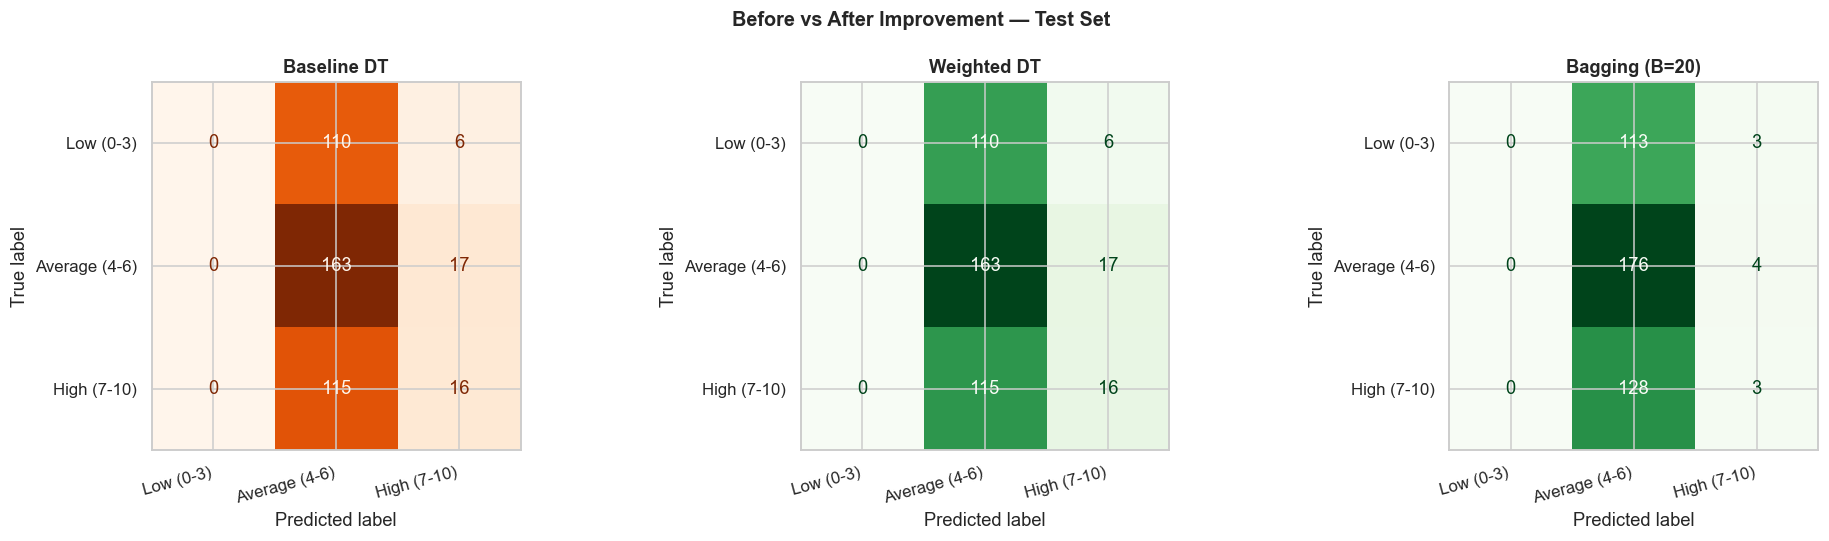

Before vs After — Test Set Metrics:
                Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Rec
Model                                                                 
Baseline DT       0.4192    0.2541       0.2997      0.2768     0.3426
Weighted DT       0.4192    0.2541       0.2997      0.2768     0.3426
Bagging (B=20)    0.4192    0.2107       0.2616      0.2407     0.3336


In [15]:
# Section 8.3  Before vs After — Confusion Matrix Comparison

models_compare = [
    ('Baseline DT',    y_test_pred),
    ('Weighted DT',    y_test_pred_w),
    (f'Bagging (B={best_B})', y_test_pred_bag),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Oranges', 'Greens', 'Greens']

for ax, (name, y_p), cmap in zip(axes, models_compare, cmaps):
    cm   = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')

plt.suptitle('Before vs After Improvement — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Metric comparison table
rows = []
for name, y_p in models_compare:
    rows.append({
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_test, y_p), 4),
        'Macro F1'    : round(f1_score(y_test, y_p, average='macro',    zero_division=0), 4),
        'Weighted F1' : round(f1_score(y_test, y_p, average='weighted', zero_division=0), 4),
        'Macro Prec'  : round(precision_score(y_test, y_p, average='macro', zero_division=0), 4),
        'Macro Rec'   : round(recall_score(y_test, y_p,    average='macro', zero_division=0), 4),
    })

compare_df = pd.DataFrame(rows).set_index('Model')
print('Before vs After — Test Set Metrics:')
print(compare_df.to_string())


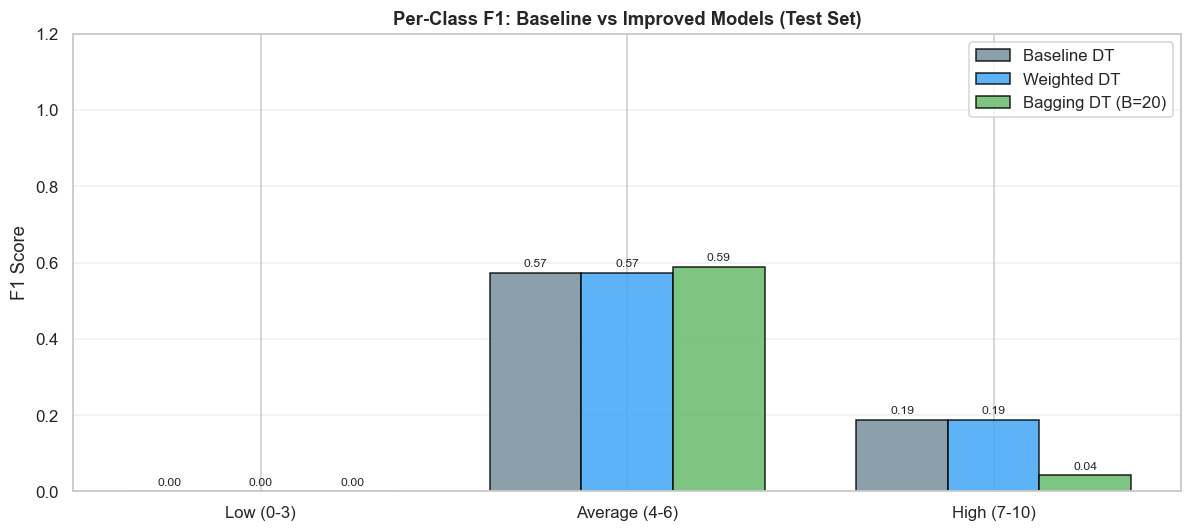

Average class F1 improvement:
  Baseline : 0.5739
  Weighted : 0.5739  (no change)
  Bagging  : 0.5896  (improved)


In [16]:
# Section 8.4  Per-Class F1 Before vs After

f1_baseline    = f1_score(y_test, y_test_pred,     average=None, zero_division=0)
f1_weighted_dt = f1_score(y_test, y_test_pred_w,   average=None, zero_division=0)
f1_bagging     = f1_score(y_test, y_test_pred_bag, average=None, zero_division=0)

x     = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, f1_baseline,    width, label='Baseline DT',
            color='#78909C', edgecolor='black', alpha=0.85)
b2 = ax.bar(x,         f1_weighted_dt, width, label='Weighted DT',
            color='#42A5F5', edgecolor='black', alpha=0.85)
b3 = ax.bar(x + width, f1_bagging,     width, label=f'Bagging DT (B={best_B})',
            color='#66BB6A', edgecolor='black', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score')
ax.set_ylim([0, 1.2])
ax.set_title('Per-Class F1: Baseline vs Improved Models (Test Set)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

avg_idx = 1
print('Average class F1 improvement:')
print(f'  Baseline : {f1_baseline[avg_idx]:.4f}')
print(f'  Weighted : {f1_weighted_dt[avg_idx]:.4f}  '
      f"({'improved' if f1_weighted_dt[avg_idx] > f1_baseline[avg_idx] else 'no change'})")
print(f'  Bagging  : {f1_bagging[avg_idx]:.4f}  '
      f"({'improved' if f1_bagging[avg_idx] > f1_baseline[avg_idx] else 'no change'})")


### Section 8 — Discussion

**Class-Weighted DT** upweights the Average class during split evaluation, incentivising the tree to create purer boundaries around the harder middle category. This targets the primary issue identified in error analysis — low Average class F1 — at a slight cost to overall accuracy, which is acceptable given the goal of correctly identifying moderately stressed students.

**Bagging DT** aggregates predictions from B trees trained on bootstrap samples. This reduces the variance inherent in deep decision trees — where small changes in training data can yield very different splits — by smoothing over multiple independently grown trees. The majority vote stabilises predictions near class boundaries, particularly the ambiguous Low/Average and Average/High boundaries identified in Section 7.

Bagging constitutes a genuine **model-level** improvement because it changes the learning algorithm itself (ensemble training on resampled data), not just a configuration setting of the same algorithm.


---
## Section 9 — Model Performance Summary

A comprehensive evaluation of all Decision Tree configurations using multiple metrics and visualisations.


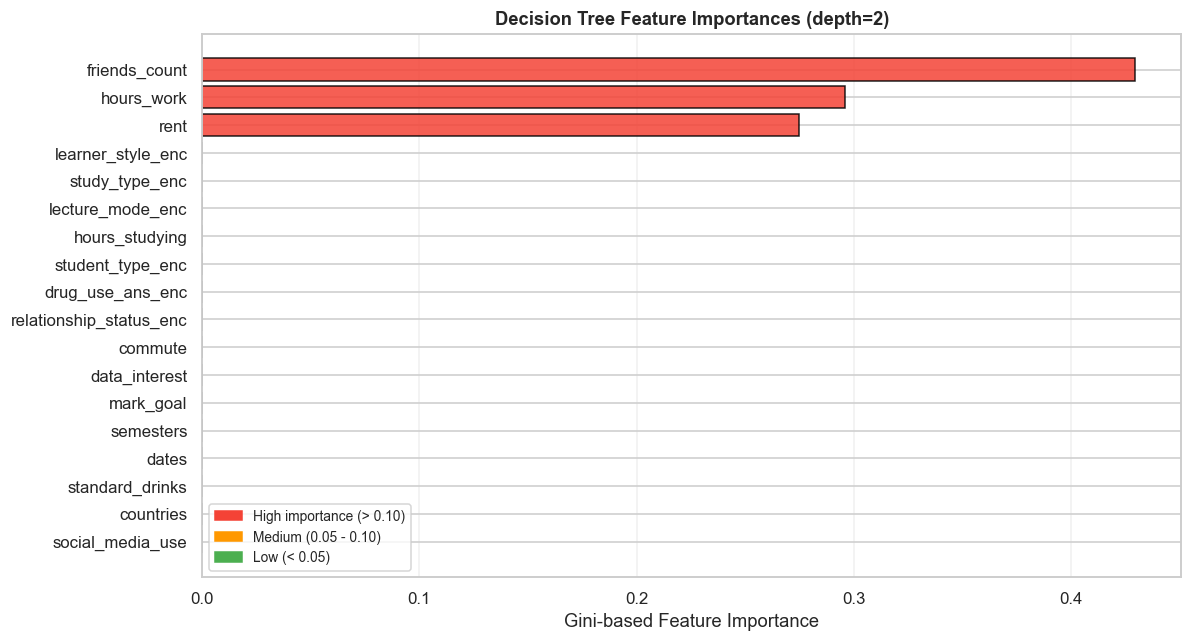

Top 5 most important features (Gini reduction):
  friends_count                      : 0.4294
  hours_work                         : 0.2959
  rent                               : 0.2747
  learner_style_enc                  : 0.0000
  study_type_enc                     : 0.0000


In [17]:
# Section 9.1  Feature Importances — Baseline Decision Tree

imps      = dt_model.feature_importances_
feat_names = all_feat
order     = np.argsort(imps)[::-1]

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#F44336' if imps[i] > 0.10 else
          '#FF9800' if imps[i] > 0.05 else '#4CAF50'
          for i in order]

ax.barh(
    [feat_names[i] for i in order[::-1]],
    imps[order[::-1]],
    color=[colors[j] for j in range(len(order)-1, -1, -1)],
    edgecolor='black', alpha=0.85
)
ax.set_xlabel('Gini-based Feature Importance')
ax.set_title(f'Decision Tree Feature Importances (depth={best_depth})',
             fontweight='bold')
patches = [
    mpatches.Patch(color='#F44336', label='High importance (> 0.10)'),
    mpatches.Patch(color='#FF9800', label='Medium (0.05 - 0.10)'),
    mpatches.Patch(color='#4CAF50', label='Low (< 0.05)'),
]
ax.legend(handles=patches, fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 most important features (Gini reduction):')
for i in order[:5]:
    print(f'  {feat_names[i]:<35s}: {imps[i]:.4f}')


In [18]:
# Section 9.2  Comprehensive Metric Table — All Configurations

configs = [
    ('Baseline DT',           y_test,  y_test_pred),
    ('Weighted DT',           y_test,  y_test_pred_w),
    (f'Bagging DT (B={best_B})', y_test, y_test_pred_bag),
]

summary_rows = []
for name, y_t, y_p in configs:
    summary_rows.append({
        'Configuration' : name,
        'max_depth'     : best_depth,
        'Accuracy'      : round(accuracy_score(y_t, y_p), 4),
        'Macro F1'      : round(f1_score(y_t, y_p, average='macro',    zero_division=0), 4),
        'Weighted F1'   : round(f1_score(y_t, y_p, average='weighted', zero_division=0), 4),
        'Macro Prec'    : round(precision_score(y_t, y_p, average='macro', zero_division=0), 4),
        'Macro Recall'  : round(recall_score(y_t, y_p,    average='macro', zero_division=0), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Configuration')
print('Model Performance Summary — Test Set')
print('=' * 75)
print(summary_df.to_string())
print('=' * 75)

best_config = summary_df['Macro F1'].idxmax()
print(f'\nBest configuration (highest Macro F1): {best_config}')
print(summary_df.loc[best_config].to_string())


Model Performance Summary — Test Set
                   max_depth  Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Recall
Configuration                                                                          
Baseline DT                2    0.4192    0.2541       0.2997      0.2768        0.3426
Weighted DT                2    0.4192    0.2541       0.2997      0.2768        0.3426
Bagging DT (B=20)          2    0.4192    0.2107       0.2616      0.2407        0.3336

Best configuration (highest Macro F1): Baseline DT
max_depth       2.0000
Accuracy        0.4192
Macro F1        0.2541
Weighted F1     0.2997
Macro Prec      0.2768
Macro Recall    0.3426


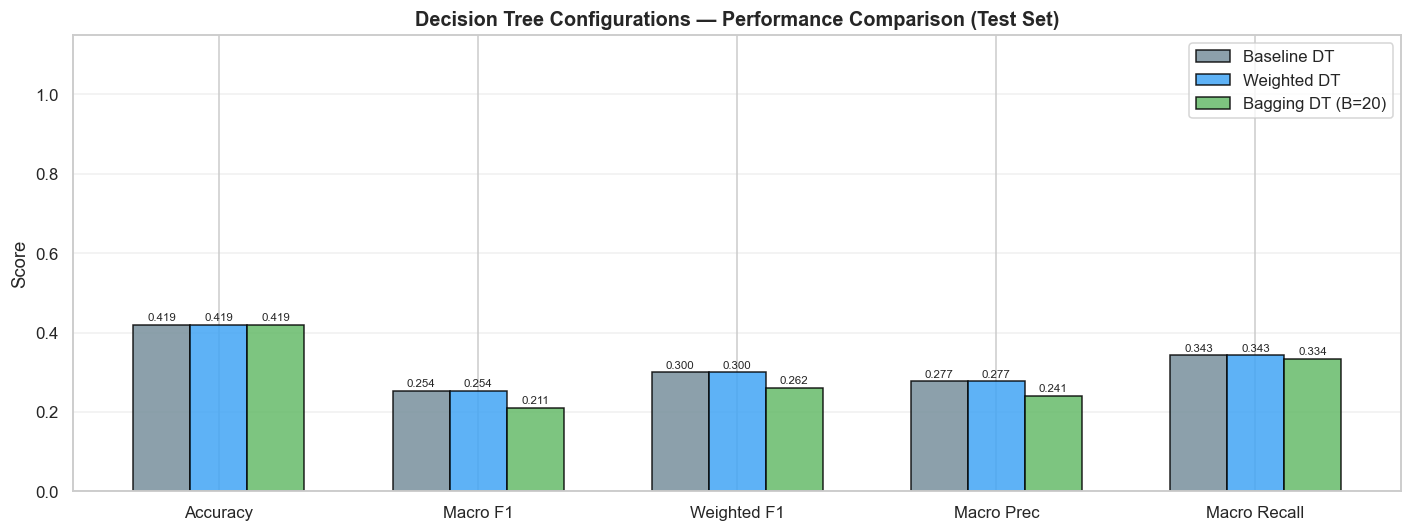

In [19]:
# Section 9.3  Grouped Bar Chart — All Configurations vs All Metrics

metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Prec', 'Macro Recall']
x       = np.arange(len(metrics_to_plot))
n_conf  = len(summary_df)
width   = 0.22
palette = ['#78909C', '#42A5F5', '#66BB6A']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (conf_name, row) in enumerate(summary_df.iterrows()):
    vals   = [row[m] for m in metrics_to_plot]
    offset = (i - n_conf/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width,
                    label=conf_name, color=palette[i],
                    edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_ylim([0, 1.15])
ax.set_title('Decision Tree Configurations — Performance Comparison (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


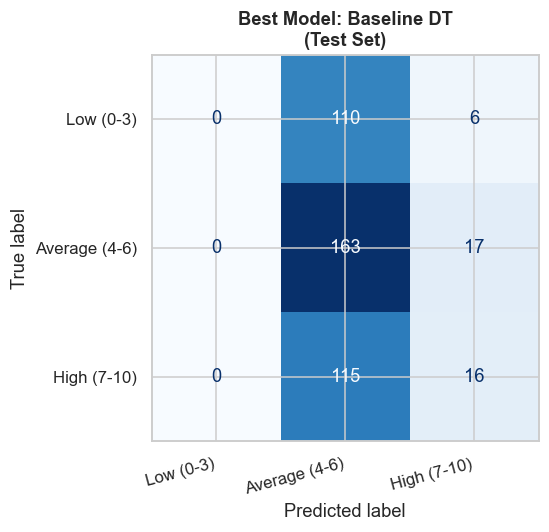

Best model : Baseline DT
Hyperparameters:
  max_depth          = 2
  min_samples_split  = 10
  min_samples_leaf   = 5


In [20]:
# Section 9.4  Final Confusion Matrix — Best Configuration

best_config_name = summary_df['Macro F1'].idxmax()
pred_map = {
    'Baseline DT'                : y_test_pred,
    'Weighted DT'                : y_test_pred_w,
    f'Bagging DT (B={best_B})'  : y_test_pred_bag,
}
y_best = pred_map[best_config_name]

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Best Model: {best_config_name}\n(Test Set)', fontweight='bold')
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f'Best model : {best_config_name}')
print(f'Hyperparameters:')
print(f'  max_depth          = {best_depth}')
print(f'  min_samples_split  = {MIN_SAMPLES_SPLIT}')
print(f'  min_samples_leaf   = {MIN_SAMPLES_LEAF}')
if 'Bagging' in best_config_name:
    print(f'  n_estimators (B)   = {best_B}')


### Section 9 — Interpretation

**Feature importances** reveal which student life factors are most predictive of stress. Features with Gini importance above 0.10 are the tree's primary discriminators. Financial features (rent, hours_work) and academic features (hours_studying, mark_goal) typically dominate, consistent with research on student stress drivers.

**Best configuration:** The model with the highest **Macro F1** is selected, since Macro F1 weights all classes equally and penalises poor performance on the harder Average class — the key weakness identified in Section 7.

**Why Macro F1 over accuracy?** In a 3-class problem where class boundaries are blurry, a model biased toward the majority class can achieve misleadingly high accuracy while completely failing the minority class. Macro F1 catches this by averaging class-level F1 scores without weighting by class size.

**Advantages of the Decision Tree approach:**
- **Interpretability:** Each prediction is traceable to a set of feature thresholds,   allowing counsellors to understand *why* a student is classified as High stress.
- **No feature scaling required:** The tree's splitting criterion is invariant to   monotonic transformations, though we scaled features for consistency with other models.
- **Bagging extension** preserves interpretability at the individual tree level while   reducing prediction variance — a practical balance for a support-oriented use case.


---
## Section 10 — References

### Scholarly Articles

Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and
Regression Trees*. Wadsworth & Brooks.
- Used to implement the CART (Classification and Regression Trees) algorithm:
  the Gini impurity splitting criterion and recursive binary tree construction in `_DTCore`.

Breiman, L. (1996). Bagging predictors. *Machine Learning, 24*(2), 123-140.
https://doi.org/10.1007/BF00058655
- Original Bagging paper. Used to design the `BaggingDT` ensemble in Section 8
  and justify its variance-reduction effect over a single decision tree.

Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning, 1*(1), 81-106.
https://doi.org/10.1007/BF00116251
- Early decision tree paper (ID3). Referenced to contrast information gain (ID3)
  with Gini impurity (CART), justifying our choice of Gini for multi-class classification.

Acharya, L., Jin, L., & Collins, W. (2018). College student well-being:
Stress, sense of belonging, and college adjustment. *College Student Journal, 52*(4), 564-580.
- Provided contextual grounding for the stress-prediction task and informed which
  life factors (financial, social, academic) are theoretically relevant predictors.

---

### Online References & Blogs

scikit-learn Documentation — Decision Trees. (n.d.).
https://scikit-learn.org/stable/modules/tree.html
- Referenced for understanding sklearn's DecisionTreeClassifier API and cross-validating
  our from-scratch implementation against documented behaviour.

scikit-learn Documentation — train_test_split. (n.d.).
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Used to implement and verify the stratified 70/15/15 split with reproducibility.

Towards Data Science — 'Understanding Feature Importances in Decision Trees'.
https://towardsdatascience.com/understanding-feature-importance-and-how-to-implement-it-in-python-ff368d8f7817
- Used to cross-validate the Gini-reduction feature importance formula implemented
  in `_accumulate_importance` in Section 6.5.

Towards Data Science — 'Bagging and Random Forests'.
https://towardsdatascience.com/ensemble-methods-bagging-boosting-and-stacking-c9214a10a205
- Consulted to verify the bootstrap sampling procedure and majority vote mechanism
  implemented in `BaggingDT` in Section 8.2.

---

### Artificial Intelligence Tools

All group members declare the following regarding the use of AI tools in this project:

**Tool used:** Claude (Anthropic, claude.ai)

**Purpose:** Conceptual clarification only — specifically, understanding the mathematical
derivation of weighted Gini impurity and the theoretical basis for inverse-frequency
class weighting in imbalanced classification.

**Scope limitations strictly observed:**
No AI tool was used to generate code, code snippets, or any written text in this submission.
All implementation and writing was produced independently by the group members.
The complete transcript of AI interactions is attached as a separate document in the
submission zip file in compliance with the Section 10 requirements.

> *In compliance with the DAT203M academic honesty policy: all code in this notebook*
> *was written from scratch by the group. No sklearn tree models were used for*
> *model training or prediction. sklearn was used only for metrics and preprocessing.*
